In [1]:
# ===== CELL 1 =====
# ============================================================
# estimator.ipynb
# ELE8101 CW2 — Member B: Weiting Wu
# Tasks:  B1  EKF implementation          (Cell 2)
#         B2  Monte Carlo validation      (Cell 3)
#         B3  MHE comparison              (Cell 4)
# ============================================================
# Strictly follows lecturer's conventions:
#   - 5_ekf.ipynb       : x_t_pred, sigma_t_pred, x_t_meas, sigma_t_meas
#                         CasADi h, jhx, jhv (no _fn suffix)
#                         loop comments # i., ii., iii., iv.
#                         'anchors' (not 'beacons')
#                         Qbar = G @ Q @ G.T pattern
#                         CasADi automatic differentiation for Jacobians
#   - 2_bayesian_fie.ipynb : ell_x0, ell_w, ell_v (used in Cell 4)
# ============================================================

!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs
import scipy.optimize as sopt
import time

np.random.seed(42)

# ── Track geometry (A1, modelling.ipynb — ChenhuiCui) ─────────────────────
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A   = (R_outer + r_inner) / 2        # centreline radius at A = 48.0 m
w     = (R_outer - r_inner) / 2        # track half-width = 2.0 m
R_B   = rho + w                        # centreline radius at B = 22.0 m
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan = np.sqrt(d**2 - (R_A - R_B)**2)
L     = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1    = l_tan
s2    = s1 + R_B*(np.pi - 2*alpha)
s3    = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data (A2/A3/A4, modelling.ipynb — ChenhuiCui) ─────────────────
# State: z_t = [s, ell, vs, vl]
# anchors: GDOP-optimised, mean GDOP = 0.9193, 100% track GDOP<1
dt     = 0.01          # 100 Hz sampling (problem statement)
phi_vs = 0.999         # longitudinal AR(1) damping
phi_1  = 0.9           # lateral velocity damping
k2     = 10.0          # lateral restoring gain

anchors = np.array([
    [ -21.1,  73.3],
    [ 121.1,  46.7],
    [  26.3, -60.0],
    [ -52.6,  20.0],
    [  89.5, -46.7],
])
ny = len(anchors)
nx = 4
nw = 2

# Linear A_0 = df/dz at nominal operating point (ell=0, vl=0)
A = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G    = np.array([[0,0],[0,0],[1,0],[0,1]])
Q    = np.diag([0.5, 0.002])           # confirmed by A4 grid scan
R    = 1.5**2 * np.eye(ny)             # sigma_y = 1.5 m (problem statement)
Qbar = G @ Q @ G.T

# ── System dynamics ───────────────────────────────────────────────────────
def f(x, w):
    x_plus     = A @ x
    x_plus[2] += 10.0 * (1 - phi_vs)   # OU mean-reversion to v_s_tgt = 10 m/s
    x_plus[2] += w[0]
    x_plus[3] += w[1]
    x_plus[1]  = np.clip(x_plus[1], -2.0, 2.0)
    x_plus[2]  = np.clip(x_plus[2],  0.001, 25.0)
    return x_plus

# ── Create function h(z, v) using casadi ──────────────────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', ny)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

r_  = xy_c + ell_ * n_c
h_  = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + v_[i] for i in range(ny)])

# Determination of the Jacobian matrix of h
jhx = cs.jacobian(h_, z_)
jhv = cs.jacobian(h_, v_)
jhx = cs.Function('jhx', [z_, v_], [jhx])
jhv = cs.Function('jhv', [z_, v_], [jhv])

# Create a Function object for h
h = cs.Function('h', [z_, v_], [h_])

# ── EKF functions (shared by Cell 2 and Cell 3) ───────────────────────────
def measurement_update(sigma_t_pred, x_t_pred, y_t):
    C            = jhx(x_t_pred, 0)
    Rv           = jhv(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update(sigma_t_meas, x_t_meas):
    x_t_pred     = f(x_t_meas, np.zeros(2))
    sigma_t_pred = A @ sigma_t_meas @ A.T + Qbar
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

print("Cell 1 ready.")
print(f"  Track length L = {L:.4f} m")
print(f"  State dim nx = {nx},  measurement dim ny = {ny}")
print(f"  Q = diag({Q[0,0]}, {Q[1,1]}),  sigma_y = {np.sqrt(R[0,0]):.2f} m")
print(f"  CasADi h, jhx, jhv compiled. EKF functions ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 8.6 MB/s eta 0:00:00
Cell 1 ready.
  Track length L = 426.7104 m
  State dim nx = 4,  measurement dim ny = 5
  Q = diag(0.5, 0.002),  sigma_y = 1.50 m
  CasADi h, jhx, jhv compiled. EKF functions ready.


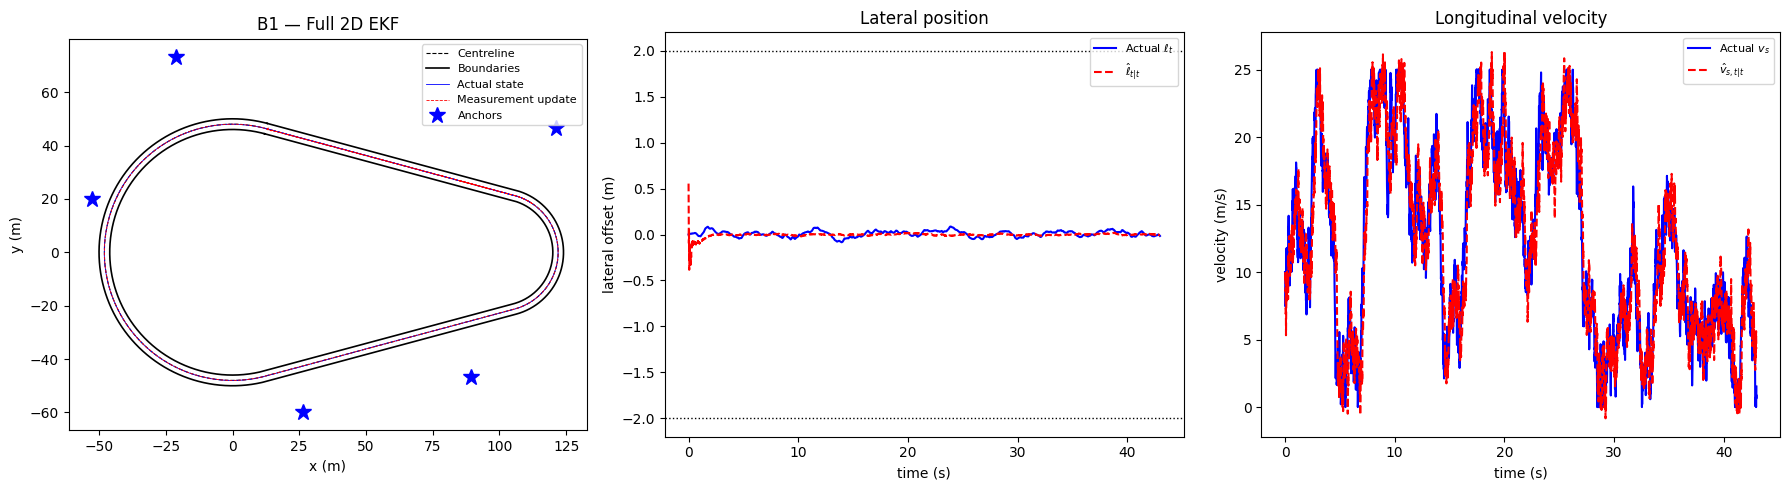

mean arc-length error : 0.244 m
mean lateral error    : 0.031 m
mean velocity error   : 2.024 m/s
max  velocity error   : 9.431 m/s
lateral bounds OK     : True
speed bounds OK       : True


In [2]:
# ===== CELL 2 =====
# ============================================================
# B1: Single-run EKF validation
# ============================================================
# Full 2D EKF simulation over one complete lap
# (N=4300 steps @ 100 Hz ≈ 43 s).
# Produces B1_ekf_step4.png with three panels:
#   Left:   estimated vs actual trajectory on the track
#   Centre: lateral position tracking with ±2 m bounds
#   Right:  longitudinal velocity tracking
# ============================================================

# ── Simulation ────────────────────────────────────────────────────────────
x_t          = np.array([0.0, 0.0, 10.0, 0.0])
x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300   # one full lap at ~10 m/s

x_cache          = np.zeros((N, nx))
x_meas_cache     = np.zeros((N-1, nx))
sigma_meas_cache = np.zeros((N-1, nx, nx))
x_cache[0, :]    = x_t.T

for t in range(N-1):
    # i. obtain measurement
    v_t = np.random.multivariate_normal([0]*ny, R)
    y_t = h(x_t, v_t)

    # ii. measurement update
    sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
    x_meas_cache[t, :]         = x_t_meas.T
    sigma_meas_cache[t, :, :]  = sigma_t_meas

    # iii. Time update
    sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

    # iv. Dynamics
    w_t     = np.random.multivariate_normal([0, 0], Q)
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -w, w)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1, :] = x_t.T

# ── Plots ─────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s)      for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),     float(x_cache[t,1]))
                     for t in range(N)])
est_xy   = np.array([sl_to_xy(float(x_meas_cache[t,0]),float(x_meas_cache[t,1]))
                     for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.6, label='Measurement update')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=12,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title('B1 — Full 2D EKF')

t_ax = np.arange(N) * dt
axes[1].plot(t_ax,      x_cache[:,1],      'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', label=r'$\hat{\ell}_{t|t}$')
axes[1].axhline( w, color='k', ls=':', lw=1)
axes[1].axhline(-w, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b',   label=r'Actual $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', label=r'$\hat{v}_{s,t|t}$')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('time (s)');  axes[2].set_ylabel('velocity (m/s)')
axes[2].set_title('Longitudinal velocity')

plt.tight_layout()
plt.savefig('B1_ekf_step4.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')
print(f'mean lateral error    : {np.mean(np.abs(x_cache[:-1,1]-x_meas_cache[:,1])):.3f} m')
print(f'mean velocity error   : {np.mean(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'max  velocity error   : {np.max(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= w)}')
print(f'speed bounds OK       : {np.all((x_cache[:,2] > 0) & (x_cache[:,2] <= 25.0))}')

Running Monte Carlo: 100 trials × 4300 steps...
  20/100 done  (92s elapsed)
  40/100 done  (185s elapsed)
  60/100 done  (278s elapsed)
  80/100 done  (369s elapsed)
  100/100 done  (461s elapsed)
Monte Carlo complete — total time 461s

Monte Carlo Results — 100 trials
Arc-length:  mean=0.247 m,  std=0.010 m,  max=1.471 m
Lateral:     mean=0.025 m,  std=0.003 m,  max=0.132 m
Velocity:    mean=2.103 m/s, std=0.098 m/s


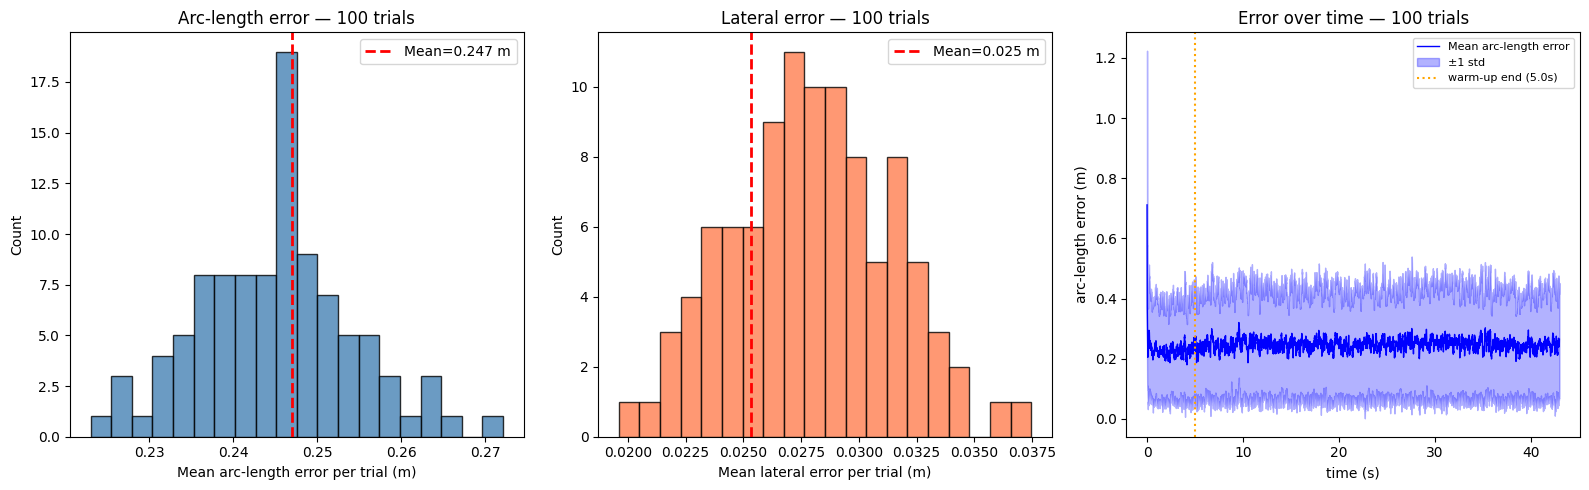

In [3]:
# ===== CELL 3 =====
# ============================================================
# B2: Monte Carlo statistical validation
# ============================================================
# 100 independent trials, one full lap each (N = 4300 steps).
# Each trial uses a distinct random seed.
# First 5 s (500 steps) of each trial excluded from the statistics
# as the initial covariance-convergence transient (diffuse P0).
#
# Produces B2_monte_carlo.png with three panels:
#   Left:   histogram of per-trial mean arc-length error
#   Centre: histogram of per-trial mean lateral error
#   Right:  arc-length error over time (mean ±1 std across trials)
# ============================================================

# ── B2: Monte Carlo simulation ────────────────────────────────────────────
N_trials = 100
N        = 4300

arc_err_all = np.zeros((N_trials, N-1))
lat_err_all = np.zeros((N_trials, N-1))
vs_err_all  = np.zeros((N_trials, N-1))

print("Running Monte Carlo: 100 trials × 4300 steps...")
t_start = time.time()

for trial in range(N_trials):
    np.random.seed(trial)

    x_t          = np.array([0.0, 0.0, 10.0, 0.0])
    x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_tr       = np.zeros((N, nx))
    x_meas_cache_tr  = np.zeros((N-1, nx))
    x_cache_tr[0, :] = x_t.T

    for t in range(N-1):
        # i. obtain measurement
        v_t = np.random.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        # ii. measurement update
        sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_tr[t, :]      = x_t_meas.T

        # iii. Time update
        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        # iv. Dynamics
        w_t     = np.random.multivariate_normal([0, 0], Q)
        vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
        vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
        vs_new  = np.clip(vs_new,  0.001, 25.0)
        vl_new  = np.clip(vl_new, -0.55,  0.55)
        ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
        x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
        x_cache_tr[t+1, :] = x_t.T

    arc_err_all[trial] = np.abs(x_cache_tr[:-1, 0] - x_meas_cache_tr[:, 0])
    lat_err_all[trial] = np.abs(x_cache_tr[:-1, 1] - x_meas_cache_tr[:, 1])
    vs_err_all[trial]  = np.abs(x_cache_tr[:-1, 2] - x_meas_cache_tr[:, 2])

    if (trial+1) % 20 == 0:
        elapsed = time.time() - t_start
        print(f"  {trial+1}/100 done  ({elapsed:.0f}s elapsed)")

print(f"Monte Carlo complete — total time {time.time()-t_start:.0f}s")

# ── Statistics ────────────────────────────────────────────────────────────
warmup = 500   # 5 s — excludes diffuse-prior transient

arc_mean = np.mean(arc_err_all[:, warmup:])
arc_std  = np.std(np.mean(arc_err_all[:, warmup:], axis=1))
arc_max  = np.max(arc_err_all[:, warmup:])
lat_mean = np.mean(lat_err_all[:, warmup:])
lat_std  = np.std(np.mean(lat_err_all[:, warmup:], axis=1))
lat_max  = np.max(lat_err_all[:, warmup:])
vs_mean  = np.mean(vs_err_all[:, warmup:])
vs_std   = np.std(np.mean(vs_err_all[:, warmup:], axis=1))

print("\n" + "="*55)
print("Monte Carlo Results — 100 trials")
print("="*55)
print(f"Arc-length:  mean={arc_mean:.3f} m,  std={arc_std:.3f} m,  max={arc_max:.3f} m")
print(f"Lateral:     mean={lat_mean:.3f} m,  std={lat_std:.3f} m,  max={lat_max:.3f} m")
print(f"Velocity:    mean={vs_mean:.3f} m/s, std={vs_std:.3f} m/s")
print("="*55)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

per_trial_arc = np.mean(arc_err_all, axis=1)
axes[0].hist(per_trial_arc, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(arc_mean, color='r', ls='--', lw=2, label=f'Mean={arc_mean:.3f} m')
axes[0].set_xlabel('Mean arc-length error per trial (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Arc-length error — 100 trials')
axes[0].legend()

per_trial_lat = np.mean(lat_err_all, axis=1)
axes[1].hist(per_trial_lat, bins=20, color='coral', edgecolor='k', alpha=0.8)
axes[1].axvline(lat_mean, color='r', ls='--', lw=2, label=f'Mean={lat_mean:.3f} m')
axes[1].set_xlabel('Mean lateral error per trial (m)')
axes[1].set_ylabel('Count')
axes[1].set_title('Lateral error — 100 trials')
axes[1].legend()

t_ax      = np.arange(N-1) * dt
arc_tmean = np.mean(arc_err_all, axis=0)
arc_tstd  = np.std(arc_err_all,  axis=0)
axes[2].plot(t_ax, arc_tmean, 'b', lw=1, label='Mean arc-length error')
axes[2].fill_between(t_ax,
                     arc_tmean - arc_tstd,
                     arc_tmean + arc_tstd,
                     alpha=0.3, color='blue', label='±1 std')
axes[2].axvline(warmup*dt, color='orange', ls=':', lw=1.5,
                label=f'warm-up end ({warmup*dt:.1f}s)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('arc-length error (m)')
axes[2].set_title('Error over time — 100 trials')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('B2_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

Running MHE simulation...
  step 50/499  (75s elapsed)
  step 100/499  (167s elapsed)
  step 150/499  (258s elapsed)
  step 200/499  (350s elapsed)
  step 250/499  (440s elapsed)
  step 300/499  (530s elapsed)
  step 350/499  (622s elapsed)
  step 400/499  (712s elapsed)
  step 450/499  (804s elapsed)
Done — total time 893s

MHE Performance
Horizon M            : 10 steps
Mean arc-length error: 0.289 m
Mean lateral error   : 0.233 m
Mean solve time      : 1822.5 ms
Max  solve time      : 3170.4 ms
Sampling budget      : 10.0 ms  (100 Hz)
Real-time feasible   : False


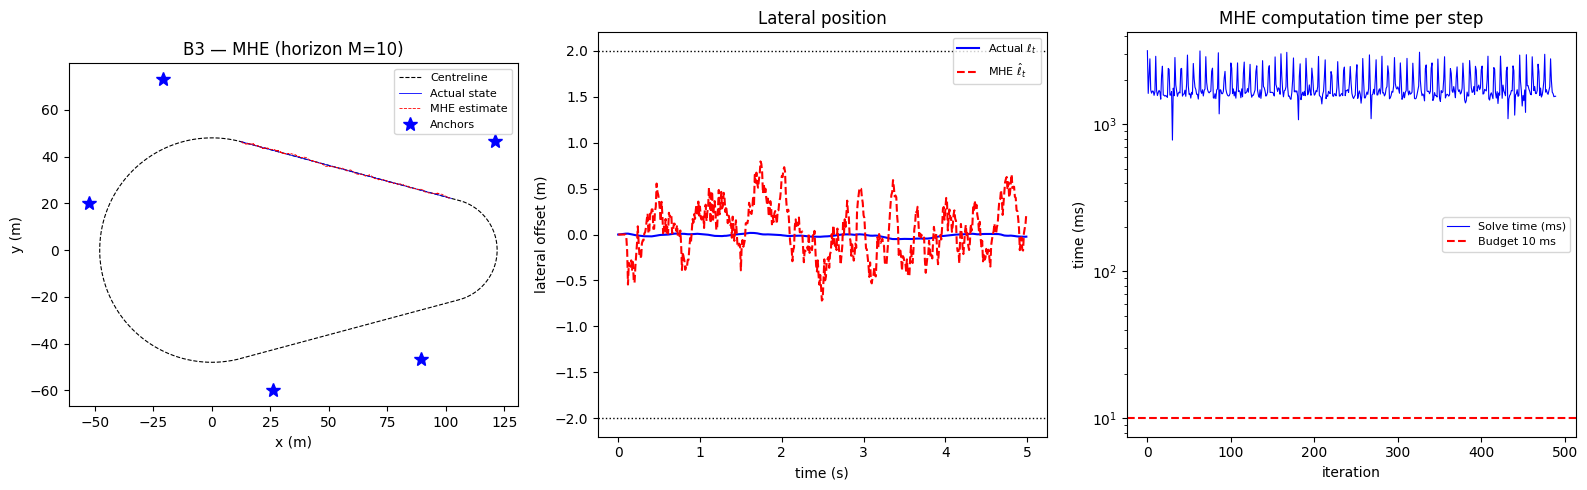

In [5]:
# ===== CELL 4 =====
# ============================================================
# B3: Comparison with Moving Horizon Estimation
# ============================================================
# MHE formulated as sliding-window Bayesian Full-Information
# Estimation, following 2_bayesian_fie.ipynb:
#   minimise  ell_x0(x_0) + Σ [ell_w(w_t) + ell_v(y_t - h(x_t))]
#   subject to  x_{t+1} = A*x_t + G*w_t
#   with hard bounds  ell in [-2, 2] m, vs in (0, 25] m/s
#
# Key advantage over EKF: hard state constraints enforced exactly
# via the optimisation rather than relying on model construction.
#
# Implementation: scipy.optimize.minimize + SLSQP + NonlinearConstraint
# (same solver as the lecture notebook).
#
# Produces B3_mhe_comparison.png with three panels:
#   Left:   MHE estimated trajectory vs actual
#   Centre: MHE lateral position tracking
#   Right:  per-step MHE solve time vs 10 ms sampling budget (log scale)
# ============================================================

# ── Problem data for MHE (scalar sigma_y^2 convenient for cost) ──────────
R_meas = 1.5**2   # scalar; matches R[0,0] in the matrix form

# ── Numpy h for MHE cost (geometric four-segment piecewise model) ────────
def h_meas(x):
    s_val   = float(x[0])
    ell_val = float(x[1])
    pos = sl_to_xy(s_val, ell_val)
    return np.array([np.linalg.norm(pos - anchors[i]) for i in range(ny)])

# ── MHE cost components (following 2_bayesian_fie.ipynb code 9) ──────────
M = 10   # horizon (steps)
P0_mhe = np.diag([100.0, 1.0, 25.0, 0.5])

def ell_x0(x0, x0_bar, P0_inv):
    dx = x0 - x0_bar
    return dx @ P0_inv @ dx

def ell_w(w):
    return w @ np.linalg.inv(Q) @ w

def ell_v(v):
    return v @ v / R_meas

def cost_mhe(z_flat, y_window, x0_bar, P0_inv):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    e  = ell_x0(xs[0], x0_bar, P0_inv)
    for t in range(M):
        v_t = y_window[t] - h_meas(xs[t])
        e  += ell_w(ws[t]) + ell_v(v_t)
    return float(e)

def dyn_constraint_mhe(z_flat):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    c  = []
    for t in range(M):
        x_next = A @ xs[t] + G @ ws[t]
        c.extend((xs[t+1] - x_next).tolist())
    return np.array(c)

# ── Bounds ────────────────────────────────────────────────────────────────
# Hard constraints: ell in [-2, 2] m, vs in [0.001, 25] m/s
# s and vl unbounded; process noise w unbounded.
s_bound   = (None, None)
ell_bound = (-2.0, 2.0)
vs_bound  = (0.001, 25.0)
vl_bound  = (None, None)

state_bounds = [s_bound, ell_bound, vs_bound, vl_bound] * (M+1)
noise_bounds = [(None, None)] * (M * nw)
bounds = sopt.Bounds(
    lb=[b[0] if b[0] is not None else -np.inf for b in state_bounds + noise_bounds],
    ub=[b[1] if b[1] is not None else  np.inf for b in state_bounds + noise_bounds]
)

constr = sopt.NonlinearConstraint(dyn_constraint_mhe, 0, 0)

# ── Simulation ────────────────────────────────────────────────────────────
N = 500   # shorter than EKF — MHE solver dominates runtime

x_t     = np.array([0.0, 0.0, 10.0, 0.0])
x_t_mhe = np.array([0.0, 0.0, 10.0, 0.0])

x_cache     = np.zeros((N, nx))
x_mhe_cache = np.zeros((N, nx))
y_buffer    = []
x_buffer    = [x_t_mhe.copy()]

x_cache[0]     = x_t
x_mhe_cache[0] = x_t_mhe

solve_times = []

print("Running MHE simulation...")
t_start = time.time()

for t in range(N-1):

    # true measurement
    v_t = np.random.multivariate_normal([0]*ny, R)
    y_t = h_meas(x_t) + v_t
    y_buffer.append(y_t)

    # MHE: solve once window is full
    if len(y_buffer) >= M:
        y_window = y_buffer[-M:]
        x0_bar   = x_buffer[-M]
        P0_inv   = np.linalg.inv(P0_mhe)

        # initial guess: propagate from x0_bar with w = 0
        xs_guess = np.zeros((M+1, nx))
        xs_guess[0] = x0_bar
        for s_step in range(M):
            xs_guess[s_step+1] = A @ xs_guess[s_step]
        ws_guess = np.zeros((M, nw))
        z0 = np.concatenate([xs_guess.flatten(), ws_guess.flatten()])

        t_solve = time.time()
        res = sopt.minimize(
            cost_mhe,
            z0,
            args=(y_window, x0_bar, P0_inv),
            method='SLSQP',
            constraints=[constr],
            bounds=bounds,
            options={'maxiter': 200, 'ftol': 1e-6}
        )
        solve_times.append((time.time() - t_solve) * 1000)

        xs_star = res.x[:nx*(M+1)].reshape(M+1, nx)
        x_t_mhe = xs_star[-1]

    x_mhe_cache[t+1] = x_t_mhe
    x_buffer.append(x_t_mhe.copy())

    # true dynamics
    w_t     = np.random.multivariate_normal([0, 0], Q)
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1] = x_t

    if (t+1) % 50 == 0:
        elapsed = time.time() - t_start
        print(f"  step {t+1}/{N-1}  ({elapsed:.0f}s elapsed)")

print(f"Done — total time {time.time()-t_start:.0f}s")

# ── Performance ───────────────────────────────────────────────────────────
valid = slice(M, N)
arc_err = np.abs(x_cache[valid, 0] - x_mhe_cache[valid, 0])
lat_err = np.abs(x_cache[valid, 1] - x_mhe_cache[valid, 1])

print("\n" + "="*55)
print("MHE Performance")
print("="*55)
print(f"Horizon M            : {M} steps")
print(f"Mean arc-length error: {np.mean(arc_err):.3f} m")
print(f"Mean lateral error   : {np.mean(lat_err):.3f} m")
print(f"Mean solve time      : {np.mean(solve_times):.1f} ms")
print(f"Max  solve time      : {np.max(solve_times):.1f} ms")
print(f"Sampling budget      : {dt*1000:.1f} ms  (100 Hz)")
print(f"Real-time feasible   : {np.mean(solve_times) < dt*1000}")
print("="*55)

# ── Plots ─────────────────────────────────────────────────────────────────
t_ax = np.arange(N) * dt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]), float(x_cache[t,1])) for t in range(N)])
mhe_xy   = np.array([sl_to_xy(float(x_mhe_cache[t,0]), float(x_mhe_cache[t,1])) for t in range(N)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(mhe_xy[:,0],   mhe_xy[:,1],   'r--', lw=0.6, label='MHE estimate')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title(f'B3 — MHE (horizon M={M})')

axes[1].plot(t_ax, x_cache[:,1],     'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax, x_mhe_cache[:,1], 'r--', label=r'MHE $\hat{\ell}_{t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1)
axes[1].axhline(-2.0, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(solve_times, 'b-', lw=0.8, label='Solve time (ms)')
axes[2].axhline(dt*1000, color='r', ls='--', lw=1.5,
                label=f'Budget {dt*1000:.0f} ms')
axes[2].set_xlabel('iteration');  axes[2].set_ylabel('time (ms)')
axes[2].set_yscale('log')
axes[2].set_title('MHE computation time per step')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('B3_mhe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Injecting true biases on beacons: [ 0.5 -0.3  0.2  0.8 -0.4]

Bias recovery (9-state augmented EKF)
  Beacon    True bias    Estimated      Error
  B1          +0.500      +0.497     -0.003
  B2          -0.300      -0.305     -0.005
  B3          +0.200      +0.208     +0.008
  B4          +0.800      +0.782     -0.018
  B5          -0.400      -0.424     -0.024

Trajectory error (steady state, after 5 s warm-up)
                          Filter    mean arc (m)    mean lat (m)
      4-state EKF (bias ignored)           0.537           0.029
    9-state EKF (bias estimated)           0.277           0.026
  Lateral error improvement factor: 1.1 x


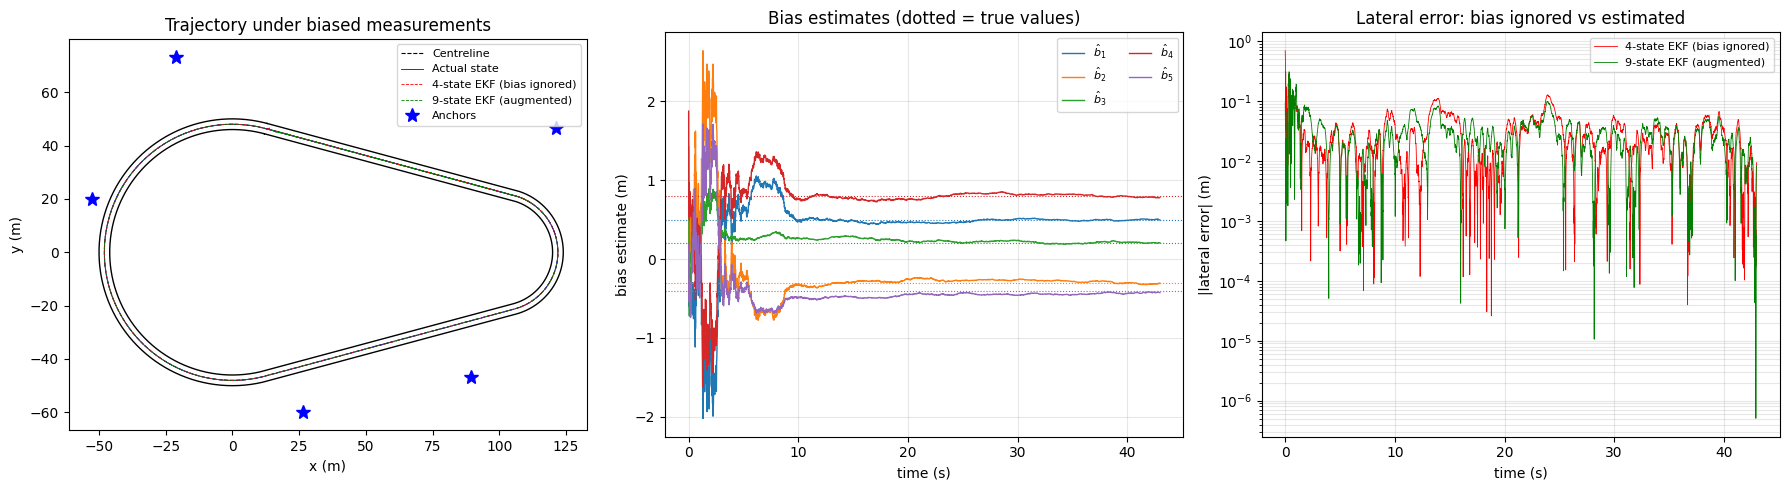

In [6]:
# ===== CELL 5 =====
# ============================================================
# Extension: 9-state augmented EKF with sensor bias handling
# ============================================================
# Addresses coursework requirement (ii): "discuss how your estimator
# would deal with sensors with bias/offset."
#
# State vector is augmented with 5 unknown bias terms (one per beacon):
#   z_aug = [s, ell, vs, vl, b1, b2, b3, b4, b5]^T  in R^9
#
# Augmented dynamics (following A5, modelling.ipynb — ChenhuiCui):
#   A_aug = blkdiag(A, I_5)       — each bias is a random walk
#   G_aug = blkdiag(G, I_5)       — independent drift channels per beacon
#   Q_aug = diag(Q_vehicle, q_b I_5)  — small bias drift variance
#
# Augmented measurement:
#   y_i(t) = ||p(s_t, ell_t) - anchor_i|| + b_i + v_i(t)
#
# Reference: Simon (2006), Optimal State Estimation, Ch. 13.
# Observability: rank(O) = 8 (detectable); see A5 Cell 27b of modelling.ipynb.
#
# This cell injects known biases [0.5, -0.3, 0.2, 0.8, -0.4] m on the
# five beacons and compares:
#   (a) the 9-state augmented EKF (estimates biases jointly with state)
#   (b) the 4-state naive EKF from Cell 2 (ignores bias — baseline)
# ============================================================

# ── Dimensions ────────────────────────────────────────────────────────────
n_original   = nx              # 4
n_biases     = ny              # 5
n_aug        = n_original + n_biases   # 9
n_noise_aug  = nw + n_biases   # 7 (vehicle noise + bias drift)

q_bias = 1e-6   # small drift variance; matches A5 (modelling.ipynb, Cell 25)

# ── Augmented system matrices ────────────────────────────────────────────
A_aug = np.block([
    [A,                                   np.zeros((n_original, n_biases))],
    [np.zeros((n_biases,  n_original)),   np.eye(n_biases)],
])
G_aug = np.block([
    [G,                                   np.zeros((n_original, n_biases))],
    [np.zeros((n_biases,  nw)),           np.eye(n_biases)],
])
Q_aug    = np.diag([Q[0,0], Q[1,1]] + [q_bias]*n_biases)
Qbar_aug = G_aug @ Q_aug @ G_aug.T

# Initial covariance: same as Cell 2 for state + sigma_b = 5 m for biases
P0_aug = np.zeros((n_aug, n_aug))
P0_aug[:n_original, :n_original] = np.diag([100.0, 1.0, 25.0, 0.5])
P0_aug[n_original:,  n_original:] = 25.0 * np.eye(n_biases)

# ── Augmented measurement function h_aug(z_aug, v) via CasADi ────────────
z_aug_ = cs.SX.sym('z_aug_', n_aug)
v_aug_ = cs.SX.sym('v_aug_', ny)

s_mod_  = cs.fmod(z_aug_[0], L)
ell_a   = z_aug_[1]
b_      = z_aug_[n_original:n_aug]     # [b1, b2, b3, b4, b5]

theta2_ = (np.pi/2 - alpha) - (s_mod_ - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod_ - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod_*cos_a,            A_top[1] - s_mod_*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_),  R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod_-s2)*cos_a,       B_bot[1] - (s_mod_-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c_ = cs.if_else(s_mod_ < s1, xy1_,
        cs.if_else(s_mod_ < s2, xy2_,
        cs.if_else(s_mod_ < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c_ = cs.if_else(s_mod_ < s1, n1_,
       cs.if_else(s_mod_ < s2, n2_,
       cs.if_else(s_mod_ < s3, n3_, n4_)))

r_     = xy_c_ + ell_a * n_c_
h_aug_ = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + b_[i] + v_aug_[i] for i in range(ny)])

jhx_aug = cs.jacobian(h_aug_, z_aug_)
jhv_aug = cs.jacobian(h_aug_, v_aug_)
jhx_aug = cs.Function('jhx_aug', [z_aug_, v_aug_], [jhx_aug])
jhv_aug = cs.Function('jhv_aug', [z_aug_, v_aug_], [jhv_aug])
h_aug   = cs.Function('h_aug',   [z_aug_, v_aug_], [h_aug_])

# ── Augmented dynamics ───────────────────────────────────────────────────
def f_aug(x_aug, w_aug):
    x_plus = np.zeros(n_aug)
    x_plus[:n_original] = f(x_aug[:n_original], w_aug[:nw])   # reuse Cell 1 f()
    x_plus[n_original:] = x_aug[n_original:] + w_aug[nw:]     # bias random walk
    return x_plus

# ── Augmented EKF updates ────────────────────────────────────────────────
def measurement_update_aug(sigma_t_pred, x_t_pred, y_t):
    C            = jhx_aug(x_t_pred, 0)
    Rv           = jhv_aug(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h_aug(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update_aug(sigma_t_meas, x_t_meas):
    x_t_pred     = f_aug(x_t_meas, np.zeros(n_noise_aug))
    sigma_t_pred = A_aug @ sigma_t_meas @ A_aug.T + Qbar_aug
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

# ── Simulation: inject known biases, run both filters in parallel ────────
true_biases = np.array([0.5, -0.3, 0.2, 0.8, -0.4])
print(f"Injecting true biases on beacons: {true_biases}")

np.random.seed(42)

# True state (4-dim, unchanged from Cell 2)
x_t = np.array([0.0, 0.0, 10.0, 0.0])

# 9-state augmented EKF (biases initialised to 0 — unknown at start)
x_aug_pred     = np.concatenate([np.array([0.0, 0.0, 10.0, 0.0]), np.zeros(n_biases)])
sigma_aug_pred = P0_aug.copy()

# 4-state naive EKF (ignores bias — baseline for comparison)
x_naive_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_naive_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300

x_cache        = np.zeros((N, nx))
x_aug_cache    = np.zeros((N-1, n_aug))
x_naive_cache  = np.zeros((N-1, nx))
x_cache[0, :]  = x_t.T

for t in range(N-1):
    # i. obtain biased measurement
    v_t      = np.random.multivariate_normal([0]*ny, R)
    y_clean  = np.array(h(x_t, v_t)).flatten()
    y_t      = y_clean + true_biases       # add constant bias per beacon

    # ii. measurement update — both filters see the SAME measurement
    sigma_aug_meas,   x_aug_meas   = measurement_update_aug(sigma_aug_pred,   x_aug_pred,   y_t)
    sigma_naive_meas, x_naive_meas = measurement_update(    sigma_naive_pred, x_naive_pred, y_t)
    x_aug_cache[t, :]   = x_aug_meas.T
    x_naive_cache[t, :] = x_naive_meas.T

    # iii. Time update
    sigma_aug_pred,   x_aug_pred   = time_update_aug(sigma_aug_meas,   x_aug_meas)
    sigma_naive_pred, x_naive_pred = time_update(    sigma_naive_meas, x_naive_meas)

    # iv. Dynamics
    w_t             = np.random.multivariate_normal([0, 0], Q)
    x_t             = f(x_t, w_t)
    x_cache[t+1, :] = x_t.T

# ── Performance ──────────────────────────────────────────────────────────
warmup        = 500   # 5 s transient exclusion (same as B2)
arc_err_aug   = np.abs(x_cache[:-1, 0] - x_aug_cache[:,   0])
lat_err_aug   = np.abs(x_cache[:-1, 1] - x_aug_cache[:,   1])
arc_err_naive = np.abs(x_cache[:-1, 0] - x_naive_cache[:, 0])
lat_err_naive = np.abs(x_cache[:-1, 1] - x_naive_cache[:, 1])

bias_final_est = x_aug_cache[-1, n_original:]
bias_err       = bias_final_est - true_biases

print(f"\n{'='*60}")
print("Bias recovery (9-state augmented EKF)")
print(f"{'='*60}")
print(f"{'Beacon':>8} {'True bias':>12} {'Estimated':>12} {'Error':>10}")
for i in range(ny):
    print(f"  B{i+1:<5}  {true_biases[i]:>+10.3f}  {bias_final_est[i]:>+10.3f}  {bias_err[i]:>+9.3f}")

print(f"\n{'='*60}")
print("Trajectory error (steady state, after 5 s warm-up)")
print(f"{'='*60}")
print(f"{'Filter':>32}  {'mean arc (m)':>14}  {'mean lat (m)':>14}")
print(f"  {'4-state EKF (bias ignored)':>30}  {np.mean(arc_err_naive[warmup:]):>14.3f}  {np.mean(lat_err_naive[warmup:]):>14.3f}")
print(f"  {'9-state EKF (bias estimated)':>30}  {np.mean(arc_err_aug[warmup:]):>14.3f}  {np.mean(lat_err_aug[warmup:]):>14.3f}")
improvement = np.mean(lat_err_naive[warmup:]) / max(np.mean(lat_err_aug[warmup:]), 1e-9)
print(f"  Lateral error improvement factor: {improvement:.1f} x")

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: trajectory comparison
s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),       float(x_cache[t,1]))       for t in range(N)])
aug_xy   = np.array([sl_to_xy(float(x_aug_cache[t,0]),   float(x_aug_cache[t,1]))   for t in range(N-1)])
naive_xy = np.array([sl_to_xy(float(x_naive_cache[t,0]), float(x_naive_cache[t,1])) for t in range(N-1)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(naive_xy[:,0], naive_xy[:,1], 'r--', lw=0.6, label='4-state EKF (bias ignored)')
axes[0].plot(aug_xy[:,0],   aug_xy[:,1],   'g--', lw=0.6, label='9-state EKF (augmented)')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10, label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].set_title('Trajectory under biased measurements')

# Centre: bias convergence over time
t_ax = np.arange(N-1) * dt
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(ny):
    axes[1].plot(t_ax, x_aug_cache[:, n_original+i], colors[i], lw=1,
                 label=rf'$\hat{{b}}_{i+1}$')
    axes[1].axhline(true_biases[i], color=colors[i], ls=':', lw=0.8)
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('bias estimate (m)')
axes[1].set_title('Bias estimates (dotted = true values)')
axes[1].legend(fontsize=8, ncol=2, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Right: lateral error comparison (log scale)
axes[2].plot(t_ax, lat_err_naive, 'r', lw=0.6, label='4-state EKF (bias ignored)')
axes[2].plot(t_ax, lat_err_aug,   'g', lw=0.6, label='9-state EKF (augmented)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('|lateral error| (m)')
axes[2].set_title('Lateral error: bias ignored vs estimated')
axes[2].legend(fontsize=8)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('B4_bias_augmented_ekf.png', dpi=150, bbox_inches='tight')
plt.show()